In [1]:
%pip install lightgbm xgboost catboost


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import joblib


from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.config import *
from src.utils import get_latest_file
pd.set_option("display.max_columns", None)

In [3]:

bets_df, summary = run_season_simulation(["2022-23", "2023-24"], exclude_future_seasons=True, 
                            min_ev=0.15,          
                            bankroll=1000, 
                            max_risk=0.02,         
                            prob_diff=0.10,        
                            odds_max=2.5,          
                            odds_min=1.2,           
                            ev_diff_min=0.10,      
                            streak_limit=5,        
                            bankroll_stop=0.2,     
                            skip_first_n=0, 
                            model_identifier="default"
                        )

print("\n=== Résumé des paris ===")
print(summary)
print("\n=== Détails des paris ===")
print(bets_df.head())


=== Simulation pour la saison 2022-23 ===
Chargement du modèle existant pour 2022-23 (default)
Modèle chargé depuis data/models/simulations/model_2022-23_default.joblib

Exemples de clés de match dans odds_df (tolérance date):
0    (2023-06-12, denver nuggets, miami heat)
1    (2023-06-09, miami heat, denver nuggets)
2    (2023-06-07, miami heat, denver nuggets)
3    (2023-06-04, denver nuggets, miami heat)
4    (2023-06-01, denver nuggets, miami heat)
Name: match_key, dtype: object

Exemples de clés de match dans nba_df:
56336     (2022-10-18, boston celtics, philadelphia 76ers)
56338    (2022-10-18, golden state warriors, los angele...
56340         (2022-10-19, detroit pistons, orlando magic)
56342     (2022-10-19, indiana pacers, washington wizards)
56344         (2022-10-19, atlanta hawks, houston rockets)
Name: match_key, dtype: object

Nombre de lignes fusionnées: 5196
Nombre de correspondances réussies: 2640
Nombre de correspondances échouées: 2556

IDs manquants TEAM_ID: []
I

In [4]:
#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)

In [5]:
bets_df

,date,game_id,team,odds,prob,ev,stake,won,gain,bankroll
0,2022-10-24,22200048.0,utah jazz,1.68,0.688341,0.156412,20.000000,0,-20.000000,980.000000
1,2022-10-24,22200049.0,memphis grizzlies,1.80,0.695125,0.251224,19.600000,1,15.680000,995.680000
2,2022-10-28,22200077.0,san antonio spurs,2.35,0.617100,0.450184,19.913600,1,26.883360,1022.563360
3,2022-10-31,22200096.0,charlotte hornets,2.25,0.732258,0.647580,20.451267,0,-20.451267,1002.112093
4,2022-11-01,22200106.0,phoenix suns,1.54,0.764328,0.177065,20.042242,1,10.822811,1012.934903
...,...,...,...,...,...,...,...,...,...,...
206,2024-05-14,42300215.0,new york knicks,1.76,0.716947,0.261827,13.295778,1,10.104791,674.893672
207,2024-05-19,42300217.0,new york knicks,1.60,0.723040,0.156864,13.497873,0,-13.497873,661.395799
208,2024-05-11,42300223.0,oklahoma city thunder,1.97,0.617117,0.215720,13.227916,0,-13.227916,648.167883
209,2024-04-16,52300131.0,sacramento kings,2.08,0.656667,0.365868,12.963358,1,14.000426,662.168309


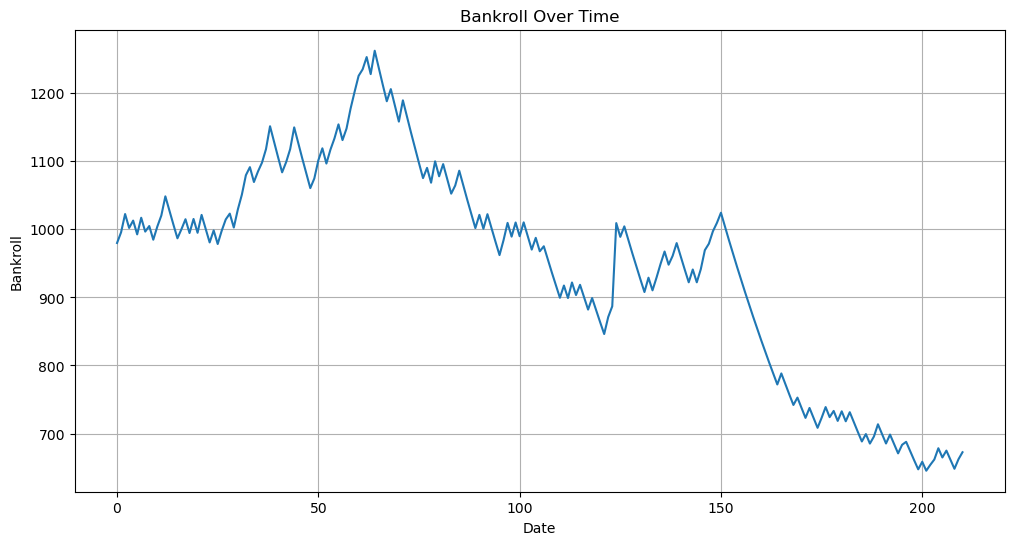

In [6]:
#plot bets_df

import matplotlib.pyplot as plt
bets_df['bankroll'].plot(kind='line', figsize=(12, 6), title='Bankroll Over Time')
plt.xlabel('Date')
plt.ylabel('Bankroll')
plt.grid()



